In [1]:
import numpy as np
import pandas as pd
import csv
import os
import os.path
import re
import fnmatch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from matplotlib.colors import rgb2hex, colorConverter
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
import seaborn as sns; sns.set(style="white", context = "paper", font_scale = 0.729, palette='colorblind', 
                               color_codes = True, rc = {"font.size":7, "xtick.bottom":True, "ytick.left":True, 
                                                         "xtick.major.size": 2, "ytick.major.size": 2})
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette
from scipy.stats.stats import pearsonr

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from bokeh.plotting import ColumnDataSource, figure, output_file, show
from bokeh.io import output_notebook, push_notebook, show
from bokeh.models.tools import HoverTool
from bokeh.layouts import row
# %pylab inline
from collections import defaultdict
from fastcluster import linkage
from functools import reduce
import math
import statsmodels.api as sm
from itertools import chain
from scipy.stats.stats import pearsonr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# Calculate the correlation between each neuronal trace (full matrix)
def Correlation (traces_z):
        
    """
    Calculation of pearson correlation coefficient between two cells (full matrix)
    
    """
    
    PCC_matrix = []
    for i in np.arange(len(traces_z)):
        PCC = []
        for a in np.arange(len(traces_z)):
            b = pearsonr(traces_z[i][~(np.isnan(traces_z[i]))], traces_z[a][~(np.isnan(traces_z[a]))])

            PCC.append(b[0])                  #only append correlation value
        PCC_matrix.append(PCC)

    return PCC_matrix

In [3]:
# Calculate the correlation between each neuronal trace (half matrix)
def Correlation_half_matrix (traces_z, number, genotype, drink):
        
    """
    Calculation of pearson correlation coefficient between two cells (half matrix)
    
    """
    Cell_list_1 = []
    Cell_list_2 = []
    PCC_matrix = []
    for i in np.arange(len(traces_z)):
        PCC = []
        for a in np.arange(len(traces_z)):
            if i < a:
                b = pearsonr(traces_z[i][~(np.isnan(traces_z[i]))], traces_z[a][~(np.isnan(traces_z[a]))])

                PCC.append(b[0])                  #only append correlation value
                Cell_list_1.append(i+1)
                Cell_list_2.append(a+1)
            
        PCC_matrix.append(PCC)
        PCC_list = list(chain(*PCC_matrix))
        
        df_PCC = pd.DataFrame(list(zip(PCC_list, Cell_list_1, Cell_list_2)), columns = ["PCC", "Cell_1_ID", "Cell_2_ID"])
        df_PCC["Number"] = number
        df_PCC["Genotype"] = genotype
        df_PCC["Drink"] = drink
    return df_PCC

In [4]:
# Calculate the correlation between each neuronal activity and its belonging ensemble activity
def Correlation_between_single_and_ensemble (single, ensemble):
        
    """
    Calculation of pearson correlation coefficient between single and ensemble activity
    
    """   
    
    sig = single.loc[:, single.columns != "Cluster"]
    
    PCC = []
    for i in np.arange(len(sig)):
        b= pearsonr(sig.iloc[i][~(np.isnan(sig.iloc[i]))], 
                    ensemble[~(np.isnan(ensemble))])
        
        PCC.append(b[0])                  #only append correlation value

    return PCC

In [5]:
# Calculate Within Cluster Sum of Squares (WCSS)
def WCSS (PCC, number, drink):
    
    """
    PCC: PCC matrix
    number: NO. of mouse
    drink: drink

    """
    
    wcss = []
    for i in range(1, 7):
        kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
        kmeans.fit(PCC)
        wcss.append(kmeans.inertia_)

    return wcss

In [6]:
# Plot clustermap (related to Supplementary Fig. 5, 6)
def Clustermap (df_matrix, number, drink, row_c):
    
    """
    df_matrix: PCC matrix
    number: NO. of mouse
    drink: drink
    row_c: row color
    
    """

    sn = sns.clustermap(df_matrix.loc[:, df_matrix.columns != "Cluster"], vmin=-1, vmax=1, 
                        method='ward', cmap="bwr", metric='euclidean', 
                        linewidths=0, annot_kws={"size": 30}, cbar_pos=(1.05, 0.03, 0.03, 0.765), 
                        cbar_kws={'label': 'Correlation coeff.'}, xticklabels=1, yticklabels=1,
                        row_colors=df_matrix['Cluster'].map(row_c),
                        col_colors=df_matrix['Cluster'].map(row_c))

    ax = sn.ax_heatmap
    label_y = ax.get_yticklabels()
    label_x = ax.get_xticklabels()
    plt.setp(label_y, rotation=0, horizontalalignment='left', fontsize=10)
    plt.setp(label_x, fontsize=10)
    ax.set_xlabel("Neuron", fontsize=10)
    ax.set_ylabel("Neuron", rotation=270 ,fontsize=10, horizontalalignment='center')
    ax.xaxis.set_label_coords(.5, -.07)
    ax.yaxis.set_label_coords(1.07, .5)
    sn.fig.set_size_inches(8, 8)

    if not os.path.exists(savefig+number): os.mkdir(savefig+number)
    if not os.path.exists(savefig+number+"/"+drink): os.mkdir(savefig+number+"/"+drink)
    
    plt.savefig(savefig+number+"/"+drink+"/Clustermap.pdf", transparent=True, bbox_inches="tight")
    
    plt.close()

In [8]:
# Relabel ensemble 1 and 2 via correlation between ensemble activity and behavior
def Relabel_OE (df_z_score, target_int, number, drink, BF):
    
    """
    df_z_score: Normalized neuronal activity
    target_int: Cell order
    number: NO. of mouse
    drink: drink
    BF: blank frames
    
    """
    
    # Separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)

    #################################################################
    # Read social interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_OE_behavior_period.csv", index_col=None, header=None)

    # Create OE time point list
    OE_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        OE_list1.append(b)

    # Convert multi-dimension list into one dimension list
    OE_list = list(chain(*OE_list1))
    BF = list(chain(*BF))
    new_OE_list = []
    
    #Convert social peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_OE_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_OE_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_OE_list:
        if i in OE_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)

    #################################################################
    # Calculate correlation between ensemble1 and ensemble2
    Ensemble1_behavior_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], Interaction_mask)
    
    Ensemble2_behavior_PCC = pearsonr(cluster2_average[~(np.isnan(cluster2_average))], Interaction_mask)
    
    if Ensemble1_behavior_PCC[0] < Ensemble2_behavior_PCC[0]:
        df_z_score["Cluster"] = df_z_score["Cluster"].map({1:2, 2:1})

    new_label = df_z_score["Cluster"].tolist()

    return new_label


In [9]:
# Calculate the correlation between ensemble activity and behavior
def Correlation_between_ensemble_and_OE_behavior (df_z_score, target_int, number, drink, BF):
    
    """
    df_z_score: Normalized neuronal activity
    target_int: Cell order
    number: NO. of mouse
    drink: drink
    BF: blank frames
    
    """
    
    # Separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)

    #################################################################
    # Read social interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_OE_behavior_period.csv", index_col=None, header=None)

    # Create OE time point list
    OE_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        OE_list1.append(b)

    # Convert multi-dimension list into one dimension list
    OE_list = list(chain(*OE_list1))
    BF = list(chain(*BF))
    new_OE_list = []
    
    # Convert social peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_OE_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_OE_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_OE_list:
        if i in OE_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)

    #################################################################
    # Calculate correlation between ensemble1 and ensemble2
    Ensemble1_behavior_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], Interaction_mask)
    Ensemble2_behavior_PCC = pearsonr(cluster2_average[~(np.isnan(cluster2_average))], Interaction_mask)

    return [Ensemble1_behavior_PCC[0], Ensemble2_behavior_PCC[0]]


In [10]:
# Calculate pcc between ensemble1 and ensemble2 and draw activity
def PCCs_OE (df_z_score, target_int, number, drink, BF):
    #separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
    cluster1_sem = np.std(cluster1.loc[:, cluster1.columns != "Cluster"])/ np.sqrt(len(cluster1))

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
    cluster2_sem = np.std(cluster2.loc[:, cluster2.columns != "Cluster"])/ np.sqrt(len(cluster2))

    #################################################################
    #calculate correlation between ensemble1 and ensemble2
    Ensemble_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], 
                            cluster2_average[~(np.isnan(cluster2_average))])

    #################################################################
    #calculate PCC between single and ensemble activity
    Cluster1_pcc = Correlation_between_single_and_ensemble (cluster1, cluster1_average)
    Cluster2_pcc = Correlation_between_single_and_ensemble (cluster2, cluster2_average)
    
    Both_Cluster_pcc = Cluster1_pcc + Cluster2_pcc

    #################################################################
    # Read object interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_OE_behavior_period.csv", index_col=None, header=None)

    # Create OE time point list
    OE_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        OE_list1.append(b)

    # Convert multi-dimension list into one dimension list
    OE_list = list(chain(*OE_list1))
    
    BF = list(chain(*BF))
    new_OE_list = []
    # Convert object peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_OE_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_OE_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_OE_list:
        if i in OE_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)
    
    #################################################################
    # Calculate correlation between individual neuron activity and behavior
    sig = df_z_score.loc[:, df_z_score.columns != "Cluster"]
    
    Single_behavior_PCC = []
    for i in np.arange(len(sig)):
        b= pearsonr(sig.iloc[i][~(np.isnan(sig.iloc[i]))], 
                    Interaction_mask)

        Single_behavior_PCC.append(b[0])                  #only append correlation value

    return Both_Cluster_pcc, Single_behavior_PCC

In [19]:
# Relabel the ensemble (Higher correlation between activity and behavior -> Ensemble 1)
def Relabel_RSI (df_z_score, target_int, number, drink, BF):
    
    """
    df_z_score: Normalized neuronal activity
    target_int: Cell order
    number: NO. of mouse
    drink: drink
    BF: blank frames
    
    """
    
    # Separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)

    #################################################################
    # Read social interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_RSI_behavior_period.csv", index_col=None, header=None)

    # Create RSI time point list
    RSI_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        RSI_list1.append(b)

    # Convert multi-dimension list into one dimension list
    RSI_list = list(chain(*RSI_list1))
    
    BF = list(chain(*BF))
    new_RSI_list = []
    # Convert social peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_RSI_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_RSI_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_RSI_list:
        if i in RSI_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)

    #################################################################
    # Calculate correlation between ensemble1 and ensemble2
    Ensemble1_behavior_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], Interaction_mask)
    
    Ensemble2_behavior_PCC = pearsonr(cluster2_average[~(np.isnan(cluster2_average))], Interaction_mask)
    
    if Ensemble1_behavior_PCC[0] < Ensemble2_behavior_PCC[0]:
        df_z_score["Cluster"] = df_z_score["Cluster"].map({1:2, 2:1})

    new_label = df_z_score["Cluster"].tolist()

    return new_label


In [20]:
# Calculate the correlation between ensemble activity and behavior
def Correlation_between_ensemble_and_RSI_behavior (df_z_score, target_int, number, drink, BF):
    
    """
    df_z_score: Normalized neuronal activity
    target_int: Cell order
    number: NO. of mouse
    drink: drink
    BF: blank frames
    
    """
    
    # Separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)

    #################################################################
    # Read social interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_RSI_behavior_period.csv", index_col=None, header=None)

    # Create RSI time point list
    RSI_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        RSI_list1.append(b)

    #convert multi-dimension list into one dimension list
    RSI_list = list(chain(*RSI_list1))
    
    BF = list(chain(*BF))
    new_RSI_list = []
    # Convert social peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_RSI_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_RSI_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_RSI_list:
        if i in RSI_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)

    #################################################################
    # Calculate correlation between ensemble1 and ensemble2
    Ensemble1_behavior_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], Interaction_mask)
    Ensemble2_behavior_PCC = pearsonr(cluster2_average[~(np.isnan(cluster2_average))], Interaction_mask)

    return [Ensemble1_behavior_PCC[0], Ensemble2_behavior_PCC[0]]


In [21]:
# Calculate pcc between ensemble1 and ensemble2 and draw activity
def PCCs_RSI (df_z_score, target_int, number, drink, BF):
        
    """
    df_z_score: Normalized neuronal activity
    target_int: Cell order
    number: NO. of mouse
    drink: drink
    BF: blank frames
    
    """
    
    # Separate cluster1 and cluster2
    cluster1 = df_z_score[df_z_score["Cluster"]==1]
    cluster1.index = cluster1.index+1
    cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
    cluster1_sem = np.std(cluster1.loc[:, cluster1.columns != "Cluster"])/ np.sqrt(len(cluster1))

    cluster2 = df_z_score[df_z_score["Cluster"]==2]
    cluster2.index = cluster2.index+1
    cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
    cluster2_sem = np.std(cluster2.loc[:, cluster2.columns != "Cluster"])/ np.sqrt(len(cluster2))

    #################################################################
    # Calculate correlation between ensemble1 and ensemble2
    Ensemble_PCC = pearsonr(cluster1_average[~(np.isnan(cluster1_average))], 
                            cluster2_average[~(np.isnan(cluster2_average))])

    #################################################################
    # Calculate PCC between single neuronal activity and its belonging ensemble activity
    Cluster1_pcc = Correlation_between_single_and_ensemble (cluster1, cluster1_average)
    Cluster2_pcc = Correlation_between_single_and_ensemble (cluster2, cluster2_average)
    Both_Cluster_pcc = Cluster1_pcc + Cluster2_pcc

    #################################################################
    # Read social interaction time
    Interaction = pd.read_csv(fdir1+ "/"+ drink +"_" + nm + "_RSI_behavior_period.csv", index_col=None, header=None)

    # Create RSI time point list
    RSI_list1 = []
    for a in range(len(Interaction.T)):
        b= list(range(Interaction[a][0], Interaction[a][1],1))
        RSI_list1.append(b)

    # Convert multi-dimension list into one dimension list
    RSI_list = list(chain(*RSI_list1))
    BF = list(chain(*BF))
    new_RSI_list = []
    
    # Convert social peroid to binary mask (remove nan)
    record_list = np.arange(6000)
    if BF != []:
        new_RSI_list = [ele for ele in record_list if ele not in BF]
        
    else:
        new_RSI_list = [ele for ele in record_list]
        
    Interaction_mask = []
    for i in new_RSI_list:
        if i in RSI_list:
            Interaction_mask.append(1)
        else:
            Interaction_mask.append(0)  
    
    Interaction_mask = np.array(Interaction_mask)
    
    #################################################################
    # Calculate correlation between individual neuron activity and behavior
    sig = df_z_score.loc[:, df_z_score.columns != "Cluster"]
    
    Single_behavior_PCC = []
    for i in np.arange(len(sig)):
        b= pearsonr(sig.iloc[i][~(np.isnan(sig.iloc[i]))], 
                    Interaction_mask)

        Single_behavior_PCC.append(b[0])                  #only append correlation value

    return Both_Cluster_pcc, Single_behavior_PCC

# Mice information and treatment

In [7]:
WT_Number = ["NO.1", "NO.2", "NO.8", "NO.15"]
Tbr1_Number = ["NO.3", "NO.13", "NO.16", "NO.20"]
Drinks = ["Water", "Cocktail"]

# Analysis of object_exploration_linked_neurons

In [11]:
# Create files
if not os.path.exists("Results"): os.mkdir("Results")
if not os.path.exists("Results/Ensemble"): os.mkdir("Results/Ensemble")
# if not os.path.exists("Results/Ensemble/output_csv"): os.mkdir("Results/Ensemble/output_csv")
# if not os.path.exists("Results/Ensemble/output_csv/object_exploration_linked_neurons"): os.mkdir("Results/Ensemble/output_csv/object_exploration_linked_neurons")
if not os.path.exists("Results/Ensemble/figure"): os.mkdir("Results/Ensemble/figure")
if not os.path.exists("Results/Ensemble/figure/object_exploration_linked_neurons"): os.mkdir("Results/Ensemble/figure/object_exploration_linked_neurons")

savefig = "Results/Ensemble/figure/object_exploration_linked_neurons/"
# savecsv = "Results/Ensemble/output_csv/object_exploration_linked_neurons/"

In [12]:
#WT data analysis
WT_Single_ensemble_PCC = pd.DataFrame([])
WT_Single_behavior_PCC = pd.DataFrame([])
WT_Ensemble_behavior_PCC = pd.DataFrame([])
WT_WCSS = pd.DataFrame([])
WT_pcc_matrix = pd.DataFrame([])
WT_ensemble = pd.DataFrame([])

for nm in WT_Number:
    
    # Read Multi-session registration file
    WT_MSR = pd.read_csv('./Calcium_imaging_data/Multi-session_registration_'+ nm +'.csv', index_col=0, header =0 )
    WT_MSR_OE = WT_MSR[["Water_OE", "Cocktail_OE"]]
    WT_MSR_OE1 = WT_MSR_OE.copy(deep=True)
    WT_MSR_OE2 = WT_MSR_OE.copy(deep=True)
    
    
    # Read activity of water and cocktail group
    for dr in Drinks:
        print(nm, dr)
        blankfile = ""
        fdir1 = "./Calcium_imaging_data/"+ dr + "/" + nm + "/OE"

        for filename in os.listdir(fdir1):
            if fnmatch.fnmatch(filename, '*blank*.csv'): blankfile = fdir1 + "/" + filename
                
        BF = []
        if (blankfile != ""):
            BF = pd.read_csv(blankfile, index_col=0, header=0).values          
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z_6000.csv", index_col=0, header=0).values

        else:
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z.csv", index_col=0, header=0).values
            
        #calculate correlation
        pcc = Correlation (z_score_activity)
        df_matrix = pd.DataFrame(pcc, index=np.arange(len(pcc[0][:]))+1, columns=np.arange(len(pcc[:][0]))+1)

        # Plot clustermap
        sn = sns.clustermap(df_matrix, vmin=-1, vmax=1, method='ward', cmap="bwr", metric='euclidean', 
                            linewidths=0, annot_kws={"size": 30}, cbar_pos=(1.05, 0.03, 0.03, 0.765), 
                            cbar_kws={'label': 'Correlation coeff.'}, xticklabels=1, yticklabels=1)
        plt.close()

        #########################################################################
        # Sort the values for the bar plot to have the same order as clusters
        target = [t.get_text() for t in np.array(sn.ax_heatmap.get_yticklabels())]
        target_int = [int(i) for i in target]
#         print("Cell order: ", target_int)

        #########################################################################
        # Calculate WCSS
        wcss = WCSS(df_matrix, nm, dr)

        #########################################################################
        # K-mean clustering
        kmeans = KMeans (n_clusters=2, random_state=0)
        km_r = kmeans.fit(df_matrix)
        km_r.labels_= km_r.labels_+1

        df_matrix["Cluster"] = km_r.labels_

        df_z_score = pd.DataFrame(z_score_activity)
        df_z_score["Cluster"] = km_r.labels_

        
        # Relabel by correlation between ensemble activity and behavior
        new_label = Relabel_OE (df_z_score, target_int, nm, dr, BF)
        
        df_z_score.drop(["Cluster"], axis=1, inplace=True)
        df_matrix.drop(["Cluster"], axis=1, inplace=True)
        
        df_z_score["Cluster"] = new_label
        df_matrix["Cluster"] = new_label
        
        # Plot clustermap
        row_c = {1: '#ffaa49', 2: '#4641e5'}
        Clustermap(df_matrix, nm, dr, row_c)

        # Calculate pcc between ensemble1 and ensemble2 and draw activity
        Cluster_PCC, Sig_beh_PCC = PCCs_OE (df_z_score, target_int, nm, dr, BF)
        
        #########################################################################
        # Output the list of the PCC
        pcc_half = Correlation_half_matrix (z_score_activity, nm, "WT", dr)
    
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
    
        # Output pcc between individual neuron and ensemble activity
        df_PCC = pd.DataFrame(list(zip(target_int,Cluster_PCC)), 
                              columns = ["cell ID", "Cluster_PCC"])
        df_PCC.set_index("cell ID", inplace=True)

        key = dr + "_OE"    
        WT_MSR_OE1[key] = WT_MSR_OE1[key].map({i: df_PCC.loc[i]["Cluster_PCC"]  for i in df_PCC.index})        
        WT_MSR_OE1["Mouse"] = nm
        
        # Output pcc between individual neuron activity and behavior
        df_Sig_beh_PCC = pd.DataFrame(list(zip(target_int, Sig_beh_PCC)), 
                                      columns = ["cell ID", "PCC"])
        df_Sig_beh_PCC.set_index("cell ID", inplace=True)
        

        WT_MSR_OE2[key] = WT_MSR_OE2[key].map({j: df_Sig_beh_PCC.loc[j]["PCC"]  for j in df_Sig_beh_PCC.index})        
        WT_MSR_OE2["Mouse"] = nm
        #########################################################################
        # Calculate pcc between behavior and ensemble activity
        Ensemble_behavior_PCC = Correlation_between_ensemble_and_OE_behavior(df_z_score, target_int, nm, dr, BF)
        
        ensemble_list = [1,2]
        df_ensemble_behavior_PCC = pd.DataFrame(list(zip(ensemble_list, Ensemble_behavior_PCC)), 
                                                columns = ["Ensemble", "PCC"])
        
        key2 = "WT_" + dr
        df_ensemble_behavior_PCC["Group"] = key2
        df_wcss = pd.DataFrame(zip(wcss, list(range(1, 7))), columns = ["WCSS", "Cluster"])
        df_wcss["Group"] = key2
        
        df_ensemble = pd.DataFrame(zip(df_matrix.index, df_matrix["Cluster"]), columns = ["Number", "Ensemble"])
        df_ensemble["Group"] = key2

        if not os.path.exists(savecsv + nm): os.mkdir(savecsv + nm)
            
        WT_Ensemble_behavior_PCC = WT_Ensemble_behavior_PCC.append(df_ensemble_behavior_PCC, ignore_index=True)
        WT_WCSS = WT_WCSS.append(df_wcss, ignore_index=True)
        WT_pcc_matrix = WT_pcc_matrix.append(pcc_half, ignore_index = True)
        WT_ensemble = WT_ensemble.append(df_ensemble, ignore_index=True)
    # WT_MSR_OE1.to_csv(savecsv + nm + "/Single_ensemble_PCC.csv")
    # WT_MSR_OE2.to_csv(savecsv + nm + "/Single_behavior_PCC.csv")
    # WT_ensemble.to_csv(savecsv + nm + "/Ensemble.csv")
    WT_Single_ensemble_PCC = WT_Single_ensemble_PCC.append(WT_MSR_OE1, ignore_index=True)
    WT_Single_behavior_PCC = WT_Single_behavior_PCC.append(WT_MSR_OE2, ignore_index=True)
# WT_pcc_matrix.to_csv(savecsv + "/WT_PCC_half_matrix.csv")

NO.1 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
<ipython-input-8-0c7b5d01ddb9>:16: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-8-0c7b5d01ddb9>:20: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:6: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:11: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)


NO.1 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
<ipython-input-8-0c7b5d01ddb9>:16: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-8-0c7b5d01ddb9>:20: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:6: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:11: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)


NO.2 Water


...

C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.15 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
<ipython-input-8-0c7b5d01ddb9>:16: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-8-0c7b5d01ddb9>:20: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:6: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-10-cf9fbf2a1d50>:11: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)


NO.15 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
#Tbr1 data analysis
Tbr1_Single_ensemble_PCC = pd.DataFrame([])
Tbr1_Single_behavior_PCC = pd.DataFrame([])
Tbr1_Ensemble_behavior_PCC = pd.DataFrame([])
Tbr1_WCSS = pd.DataFrame([])
Tbr1_pcc_matrix = pd.DataFrame([])
Tbr1_ensemble = pd.DataFrame([])

for nm in Tbr1_Number:
    
    # Read Multi-session registration file
    Tbr1_MSR = pd.read_csv('./Calcium_imaging_data/Multi-session_registration_'+ nm +'.csv', index_col=0, header =0 )
    Tbr1_MSR_OE = Tbr1_MSR[["Water_OE", "Cocktail_OE"]]
    Tbr1_MSR_OE1 = Tbr1_MSR_OE.copy(deep=True)
    Tbr1_MSR_OE2 = Tbr1_MSR_OE.copy(deep=True)
    
    # Read activity of water and cocktail group
    for dr in Drinks:
        print(nm, dr)
        blankfile = ""
        fdir1 = "./Calcium_imaging_data/"+ dr + "/" + nm + "/OE"

        for filename in os.listdir(fdir1):
            if fnmatch.fnmatch(filename, '*blank*.csv'): blankfile = fdir1 + "/" + filename
                
        BF = []
        if (blankfile != ""):
            BF = pd.read_csv(blankfile, index_col=0, header=0).values          
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z_6000.csv", index_col=0, header=0).values

        else:
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z.csv", index_col=0, header=0).values
            
        # Calculate correlation
        pcc = Correlation (z_score_activity)
        df_matrix = pd.DataFrame(pcc, index=np.arange(len(pcc[0][:]))+1, columns=np.arange(len(pcc[:][0]))+1)

        # Plot clustermap
        sn = sns.clustermap(df_matrix, vmin=-1, vmax=1, method='ward', cmap="bwr", metric='euclidean', 
                            linewidths=0, annot_kws={"size": 30}, cbar_pos=(1.05, 0.03, 0.03, 0.765), 
                            cbar_kws={'label': 'Correlation coeff.'}, xticklabels=1, yticklabels=1)
        plt.close()

        #########################################################################
        # Sort the values for the bar plot to have the same order as clusters
        target = [t.get_text() for t in np.array(sn.ax_heatmap.get_yticklabels())]
        target_int = [int(i) for i in target]
#             print("Cell order: ", target_int)

        #########################################################################
        # Calculate WCSS
        wcss = WCSS(df_matrix, nm, dr)

        #########################################################################
        # K-mean clustering
        kmeans = KMeans (n_clusters=2, random_state=0)
        km_r = kmeans.fit(df_matrix)
        km_r.labels_= km_r.labels_+1

        df_matrix["Cluster"] = km_r.labels_

        df_z_score = pd.DataFrame(z_score_activity)
        df_z_score["Cluster"] = km_r.labels_
        
        # Relabel by correlation between ensemble activity and behavior
        new_label = Relabel_OE (df_z_score, target_int, nm, dr, BF)
        
        df_z_score.drop(["Cluster"], axis=1, inplace=True)
        df_matrix.drop(["Cluster"], axis=1, inplace=True)
        
        df_z_score["Cluster"] = new_label
        df_matrix["Cluster"] = new_label
        
        # Plot clustermap
        row_c = {1: '#ffaa49', 2: '#4641e5'}
        Clustermap(df_matrix, nm, dr, row_c)

        # Calculate pcc between ensemble1 and ensemble2 and draw activity
        Cluster_PCC, Sig_beh_PCC = PCCs_OE (df_z_score, target_int, nm, dr, BF)
        
        #########################################################################
        # Output the list of the PCC
        pcc_half = Correlation_half_matrix (z_score_activity, nm, "WT", dr)
    
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
    
        # Output pcc between individual neuron and ensemble activity
        df_PCC = pd.DataFrame(list(zip(target_int,Cluster_PCC)), 
                              columns = ["cell ID", "Cluster_PCC"])
        df_PCC.set_index("cell ID", inplace=True)

        key = dr + "_OE"    
        Tbr1_MSR_OE1[key] = Tbr1_MSR_OE1[key].map({i: df_PCC.loc[i]["Cluster_PCC"]  for i in df_PCC.index})        
        Tbr1_MSR_OE1["Mouse"] = nm
        
        # Output pcc between individual neuron activity and behavior
        df_Sig_beh_PCC = pd.DataFrame(list(zip(target_int, Sig_beh_PCC)), 
                                      columns = ["cell ID", "PCC"])
        df_Sig_beh_PCC.set_index("cell ID", inplace=True)
        

        Tbr1_MSR_OE2[key] = Tbr1_MSR_OE2[key].map({j: df_Sig_beh_PCC.loc[j]["PCC"]  for j in df_Sig_beh_PCC.index})        
        Tbr1_MSR_OE2["Mouse"] = nm
        #########################################################################
        # Calculate pcc between behavior and ensemble activity
        Ensemble_behavior_PCC = Correlation_between_ensemble_and_OE_behavior(df_z_score, target_int, nm, dr, BF)
        
        ensemble_list = [1,2]
        df_ensemble_behavior_PCC = pd.DataFrame(list(zip(ensemble_list, Ensemble_behavior_PCC)), 
                                                columns = ["Ensemble", "PCC"])
        
        key2 = "Tbr1_" + dr
        df_ensemble_behavior_PCC["Group"] = key2
        df_wcss = pd.DataFrame(zip(wcss, list(range(1, 7))), columns = ["WCSS", "Cluster"])
        df_wcss["Group"] = key2
        
        df_ensemble = pd.DataFrame(zip(df_matrix.index, df_matrix["Cluster"]), columns = ["Number", "Ensemble"])
        df_ensemble["Group"] = key2

        if not os.path.exists(savecsv + nm): os.mkdir(savecsv + nm)
            
        Tbr1_Ensemble_behavior_PCC = Tbr1_Ensemble_behavior_PCC.append(df_ensemble_behavior_PCC, ignore_index=True)
        Tbr1_WCSS = Tbr1_WCSS.append(df_wcss, ignore_index=True)
        Tbr1_pcc_matrix = Tbr1_pcc_matrix.append(pcc_half, ignore_index = True)
        Tbr1_ensemble = Tbr1_ensemble.append(df_ensemble, ignore_index=True)
    # Tbr1_MSR_OE1.to_csv(savecsv + nm + "/Single_ensemble_PCC.csv")
    # Tbr1_MSR_OE2.to_csv(savecsv + nm + "/Single_behavior_PCC.csv")
    # Tbr1_ensemble.to_csv(savecsv + nm + "/Ensemble.csv")
    Tbr1_Single_ensemble_PCC = Tbr1_Single_ensemble_PCC.append(Tbr1_MSR_OE1, ignore_index=True)
    Tbr1_Single_behavior_PCC = Tbr1_Single_behavior_PCC.append(Tbr1_MSR_OE2, ignore_index=True)
# Tbr1_pcc_matrix.to_csv(savecsv + "/Tbr1_PCC_half_matrix.csv")

NO.3 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.3 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.13 Water


...

C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.20 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.20 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


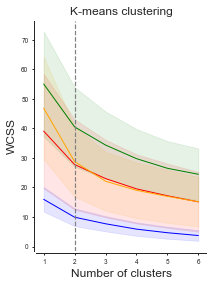

In [14]:
# Plot WCSS (related to Supplementary Fig. 5)
#Save the WCSS
WT_WCSS["Genotype"] = "WT"
Tbr1_WCSS["Genotype"] = "Tbr1"

All_WCSS = WT_WCSS.append(Tbr1_WCSS)
# All_WCSS.to_csv(savecsv + "All_WCSS.csv")

#################################################################
#separate different group
WT_Water_WCSS_mean = []
WT_Water_WCSS_sem = []

WT_Cocktail_WCSS_mean = []
WT_Cocktail_WCSS_sem = []

Tbr1_Water_WCSS_mean = []
Tbr1_Water_WCSS_sem = []

Tbr1_Cocktail_WCSS_mean = []
Tbr1_Cocktail_WCSS_sem = []

for i in range(1,7):
    WT_Water_wcss_mean = All_WCSS[(All_WCSS["Group"]== "WT_Water") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    WT_Water_wcss_sem = All_WCSS[(All_WCSS["Group"]== "WT_Water") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    WT_Water_WCSS_mean.append(WT_Water_wcss_mean[0])
    WT_Water_WCSS_sem.append(WT_Water_wcss_sem[0])
    
    WT_Cocktail_wcss_mean = All_WCSS[(All_WCSS["Group"]== "WT_Cocktail") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    WT_Cocktail_wcss_sem = All_WCSS[(All_WCSS["Group"]== "WT_Cocktail") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    WT_Cocktail_WCSS_mean.append(WT_Cocktail_wcss_mean[0])
    WT_Cocktail_WCSS_sem.append(WT_Cocktail_wcss_sem[0])
    
    Tbr1_Water_wcss_mean = All_WCSS[(All_WCSS["Group"]== "Tbr1_Water") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    Tbr1_Water_wcss_sem = All_WCSS[(All_WCSS["Group"]== "Tbr1_Water") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    Tbr1_Water_WCSS_mean.append(Tbr1_Water_wcss_mean[0])
    Tbr1_Water_WCSS_sem.append(Tbr1_Water_wcss_sem[0])
    
    Tbr1_Cocktail_wcss_mean = All_WCSS[(All_WCSS["Group"]== "Tbr1_Cocktail") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    Tbr1_Cocktail_wcss_sem = All_WCSS[(All_WCSS["Group"]== "Tbr1_Cocktail") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    Tbr1_Cocktail_WCSS_mean.append(Tbr1_Cocktail_wcss_mean[0])
    Tbr1_Cocktail_WCSS_sem.append(Tbr1_Cocktail_wcss_sem[0])
    
    
WT_Water_WCSS_mean = np.array(WT_Water_WCSS_mean)
WT_Water_WCSS_sem = np.array(WT_Water_WCSS_sem)

WT_Cocktail_WCSS_mean = np.array(WT_Cocktail_WCSS_mean)
WT_Cocktail_WCSS_sem = np.array(WT_Cocktail_WCSS_sem)

Tbr1_Water_WCSS_mean = np.array(Tbr1_Water_WCSS_mean)
Tbr1_Water_WCSS_sem = np.array(Tbr1_Water_WCSS_sem)

Tbr1_Cocktail_WCSS_mean = np.array(Tbr1_Cocktail_WCSS_mean)
Tbr1_Cocktail_WCSS_sem = np.array(Tbr1_Cocktail_WCSS_sem)


#################################################################
# Plot WCSS
plt.figure(figsize=(3,4))
x= list(range(1,7))
Group_color = ["red", "orange", "green", "blue"]


plt.plot (x, WT_Water_WCSS_mean, color=Group_color[0], linewidth=1)
plt.fill_between (x, WT_Water_WCSS_mean-WT_Water_WCSS_sem, 
                     WT_Water_WCSS_mean+WT_Water_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[0])

plt.plot (x, Tbr1_Water_WCSS_mean, color=Group_color[1], linewidth=1)
plt.fill_between (x, Tbr1_Water_WCSS_mean-Tbr1_Water_WCSS_sem, 
                     Tbr1_Water_WCSS_mean+Tbr1_Water_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[1])

plt.plot (x, WT_Cocktail_WCSS_mean, color=Group_color[2], linewidth=1)
plt.fill_between (x, WT_Cocktail_WCSS_mean-WT_Cocktail_WCSS_sem, 
                     WT_Cocktail_WCSS_mean+WT_Cocktail_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[2])

plt.plot (x, Tbr1_Cocktail_WCSS_mean, color=Group_color[3], linewidth=1)
plt.fill_between (x, Tbr1_Cocktail_WCSS_mean-Tbr1_Cocktail_WCSS_sem, 
                     Tbr1_Cocktail_WCSS_mean+Tbr1_Cocktail_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[3])


plt.title("K-means clustering", fontsize=12)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axvline(x=2, color="grey", linestyle="--")

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.tight_layout()
sns.despine(offset=2)


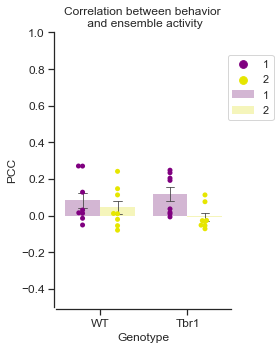

In [15]:
# Plot the correlation between behavior and ensemble activity (related to Fig. 2C; data redrawn in Prism)

# Combine PCC of WT and Tbr1
WT_Ensemble_behavior_PCC["Genotype"] = "WT"
Tbr1_Ensemble_behavior_PCC["Genotype"] = "Tbr1"

All_Ensemble_behavior_PCC = WT_Ensemble_behavior_PCC.append(Tbr1_Ensemble_behavior_PCC)
All_Ensemble_behavior_PCC

# Plot the correlation
plt.figure (figsize = (4,5))

new_spot_color1 =  {1:"purple", 2:"yellow"}
sns.set(style="ticks")
ax = sns.barplot(x="Genotype", y="PCC", hue="Ensemble", data=All_Ensemble_behavior_PCC,
                 palette=new_spot_color1,
                 alpha=0.3, errwidth=.8, capsize=.1,
                 hue_order=[1, 2], 
                 ci=68, linewidth=.0, 
                )

ax = sns.swarmplot(x="Genotype", y="PCC", hue="Ensemble", data=All_Ensemble_behavior_PCC,
                   size=5, dodge=True, alpha=1,
                   hue_order=[1,2], 
                   palette=["purple", "#E6E600"]
                  )

ax.set_xlabel(ax.get_xlabel(), size=12)
ax.set_ylabel(ax.get_ylabel(), size=12)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set(ylim=(-.5, 1))


# ax.legend_.remove()
ax.legend(loc='center left', bbox_to_anchor=(0.95, 0.8))

plt.title('Correlation between behavior \n and ensemble activity', fontsize=12)

plt.tight_layout()
sns.despine(offset=2)


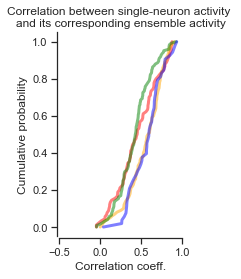

In [16]:
# Plot the correlation between single neuronal activity and its belonging ensemble activity across two OE sessions (related to Fig. 2F)
#plot figure
plt.figure (figsize = (3,4))

# plot cumulative curve
x1 = np.sort(WT_Single_ensemble_PCC["Water_OE"].dropna())  # sort data
y1 = 1.*np.arange(len(WT_Single_ensemble_PCC["Water_OE"].dropna()))/(len(WT_Single_ensemble_PCC["Water_OE"].dropna())-1)  #calculate CDF values

x2 = np.sort(Tbr1_Single_ensemble_PCC["Water_OE"].dropna())
y2 = 1.*np.arange(len(Tbr1_Single_ensemble_PCC["Water_OE"].dropna()))/(len(Tbr1_Single_ensemble_PCC["Water_OE"].dropna())-1)

x3 = np.sort(WT_Single_ensemble_PCC["Cocktail_OE"].dropna())
y3 = 1.*np.arange(len(WT_Single_ensemble_PCC["Cocktail_OE"].dropna()))/(len(WT_Single_ensemble_PCC["Cocktail_OE"].dropna())-1)

x4 = np.sort(Tbr1_Single_ensemble_PCC["Cocktail_OE"].dropna())
y4 = 1.*np.arange(len(Tbr1_Single_ensemble_PCC["Cocktail_OE"].dropna()))/(len(Tbr1_Single_ensemble_PCC["Cocktail_OE"].dropna())-1)

PCC_color = ["red", "orange", "green", "blue"]

plt.plot(x1, y1, linewidth=3, color=PCC_color[0], alpha=0.5)
plt.plot(x2, y2, linewidth=3, color=PCC_color[1], alpha=0.5)
plt.plot(x3, y3, linewidth=3, color=PCC_color[2], alpha=0.5)
plt.plot(x4, y4, linewidth=3, color=PCC_color[3], alpha=0.5)

plt.xlim([-.5,1])
plt.title("Correlation between single-neuron activity \nand its corresponding ensemble activity", fontsize=12)
plt.xlabel("Correlation coeff.", fontsize=12)
plt.ylabel("Cumulative probability", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.tight_layout()
sns.despine(offset=2)


In [17]:
from scipy import stats

# Statistic in correlation between single-neuron activity and its corresponding ensemble activity
# Two-sample KS Test
d_statistic_1, p_value_1 = stats.ks_2samp(WT_Single_ensemble_PCC["Water_OE"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Water_OE"].dropna().values)


d_statistic_2, p_value_2 = stats.ks_2samp(WT_Single_ensemble_PCC["Cocktail_OE"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Cocktail_OE"].dropna().values)


d_statistic_3, p_value_3 = stats.ks_2samp(WT_Single_ensemble_PCC["Water_OE"].dropna().values,
                                          WT_Single_ensemble_PCC["Cocktail_OE"].dropna().values)


d_statistic_4, p_value_4 = stats.ks_2samp(Tbr1_Single_ensemble_PCC["Water_OE"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Cocktail_OE"].dropna().values)


KS_name_list = ["WT_water vs. Tbr1_water", "WT_cocktail vs. Tbr1_cocktail", 
                "WT_water vs. WT_cocktail", "Tbr1_water vs. Tbr1_cocktail"]

KS_statistic_all = [d_statistic_1, d_statistic_2, d_statistic_3, d_statistic_4]
KS_p_all = [p_value_1, p_value_2, p_value_3, p_value_4]

KS_test_table_all = pd.DataFrame(list(zip(KS_name_list, KS_statistic_all, KS_p_all)), 
                                columns = ["Two-sample KS Test", "D statistic", "P-value"])

KS_test_table_all

,Two-sample KS Test,D statistic,P-value
0,WT_water vs. Tbr1_water,0.229246,0.010469
1,WT_cocktail vs. Tbr1_cocktail,0.379111,0.000023
2,WT_water vs. WT_cocktail,0.149626,0.165910
3,Tbr1_water vs. Tbr1_cocktail,0.107077,0.763336


Text(0.1, 0.96, 'pearsonr = -0.2743, p = 0.3883')

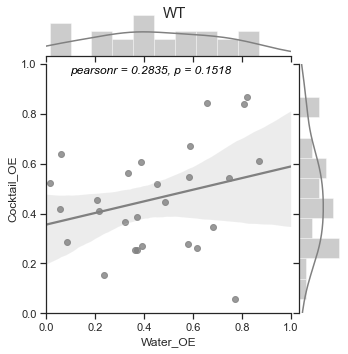

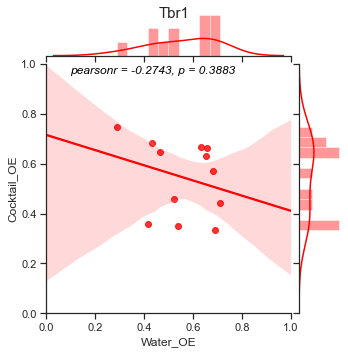

In [18]:
# Plot the correlation between single neuronal activity and its belonging ensemble activity across two OE sessions (related to Fig. 2E)

#remove nan
WT_Single_ensemble_PCC_drpona = WT_Single_ensemble_PCC.dropna(subset=["Water_OE","Cocktail_OE"])
Tbr1_Single_ensemble_PCC_drpona = Tbr1_Single_ensemble_PCC.dropna(subset=["Water_OE","Cocktail_OE"])

#WT
g1 = sns.jointplot(x="Water_OE", y="Cocktail_OE", data=WT_Single_ensemble_PCC_drpona,
                  kind="reg", truncate=False,
                  xlim=(0,1), ylim=(0,1),
                  color="grey", height=5,
                  marginal_kws=dict(bins=10)
                  )
g1.fig.suptitle('WT',fontsize=15)

r1, p1 = pearsonr(WT_Single_ensemble_PCC_drpona["Water_OE"], WT_Single_ensemble_PCC_drpona["Cocktail_OE"])
plt.text(0.1,0.96, "pearsonr = "+str(round(r1, 4))+", p = "+ str(round(p1,4)) , fontsize = 12, color='black', fontstyle='italic')


#Tbr1
g2 = sns.jointplot(x="Water_OE", y="Cocktail_OE", data=Tbr1_Single_ensemble_PCC_drpona,
                  kind="reg", truncate=False,
                  xlim=(0,1), ylim=(0,1),
                  color="red", height=5,
                  marginal_kws=dict(bins=10)
                  )
g2.fig.suptitle('Tbr1',fontsize=15)

r2, p2 = pearsonr(Tbr1_Single_ensemble_PCC_drpona["Water_OE"], Tbr1_Single_ensemble_PCC_drpona["Cocktail_OE"])
plt.text(0.1,0.96, "pearsonr = "+str(round(r2, 4))+", p = "+ str(round(p2,4)) , fontsize = 12, color='black', fontstyle='italic')


# Analysis of sociality_linked_neurons

In [22]:
# Create files
if not os.path.exists("Results"): os.mkdir("Results")
if not os.path.exists("Results/Ensemble"): os.mkdir("Results/Ensemble")
# if not os.path.exists("Results/Ensemble/output_csv"): os.mkdir("Results/Ensemble/output_csv")
# if not os.path.exists("Results/Ensemble/output_csv/sociality_linked_neurons"): os.mkdir("Results/Ensemble/output_csv/sociality_linked_neurons")
if not os.path.exists("Results/Ensemble/figure"): os.mkdir("Results/Ensemble/figure")
if not os.path.exists("Results/Ensemble/figure/sociality_linked_neurons"): os.mkdir("Results/Ensemble/figure/sociality_linked_neurons")

savefig = "Results/Ensemble/figure/sociality_linked_neurons/"
# savecsv = "Results/Ensemble/output_csv/sociality_linked_neurons/"

In [23]:
#WT data analysis
WT_Single_ensemble_PCC = pd.DataFrame([])
WT_Single_behavior_PCC = pd.DataFrame([])
WT_Ensemble_behavior_PCC = pd.DataFrame([])
WT_WCSS = pd.DataFrame([])
WT_pcc_matrix = pd.DataFrame([])
WT_ensemble = pd.DataFrame([])

for nm in WT_Number:
    
    # Read Multi-session registration file
    WT_MSR = pd.read_csv('./Calcium_imaging_data/Multi-session_registration_'+nm+'.csv', index_col=0, header=0 )
    WT_MSR_RSI = WT_MSR[["Water_RSI", "Cocktail_RSI"]]
    WT_MSR_RSI1 = WT_MSR_RSI.copy(deep=True)
    WT_MSR_RSI2 = WT_MSR_RSI.copy(deep=True)
    
    
    # Read activity of water and cocktail group
    for dr in Drinks:
        print(nm, dr)
        blankfile = ""
        fdir1 = "./Calcium_imaging_data/"+ dr + "/" + nm + "/RSI"

        for filename in os.listdir(fdir1):
            if fnmatch.fnmatch(filename, '*blank*.csv'): blankfile=fdir1+"/"+filename
                
        BF = []
        if (blankfile != ""):
            BF = pd.read_csv(blankfile, index_col=0, header=0).values          
            z_score_activity = pd.read_csv(fdir1+"/output_files/accrawt_z_6000.csv", index_col=0, header=0).values

        else:
            z_score_activity = pd.read_csv(fdir1+"/output_files/accrawt_z.csv", index_col=0, header=0).values
            
        #########################################################################    
        # Calculate the correlation between each neuronal trace
        pcc = Correlation (z_score_activity)
        df_matrix = pd.DataFrame(pcc, index=np.arange(len(pcc[0][:]))+1, columns=np.arange(len(pcc[:][0]))+1)
        
        # Plot clustermap
        sn = sns.clustermap(df_matrix, vmin=-1, vmax=1, method='ward', cmap="bwr", metric='euclidean', 
                            linewidths=0, annot_kws={"size": 30}, cbar_pos=(1.05, 0.03, 0.03, 0.765), 
                            cbar_kws={'label': 'Correlation coeff.'}, xticklabels=1, yticklabels=1)
        plt.close()
        
        #########################################################################
        # Sort the values for the bar plot to have the same order as clusters
        target = [t.get_text() for t in np.array(sn.ax_heatmap.get_yticklabels())]
        target_int = [int(i) for i in target]
#         print("Cell order: ", target_int)

        #########################################################################
        # Calculate WCSS
        wcss = WCSS(df_matrix, nm, dr)

        #########################################################################
        # K-mean clustering
        kmeans = KMeans (n_clusters=2, random_state=0)
        km_r = kmeans.fit(df_matrix)
        km_r.labels_= km_r.labels_+1

        df_matrix["Cluster"] = km_r.labels_

        df_z_score = pd.DataFrame(z_score_activity)
        df_z_score["Cluster"] = km_r.labels_
        
        # Relabel by correlation between ensemble activity and behavior
        new_label = Relabel_RSI (df_z_score, target_int, nm, dr, BF)
        
        df_z_score.drop(["Cluster"], axis=1, inplace=True)
        df_matrix.drop(["Cluster"], axis=1, inplace=True)
        
        df_z_score["Cluster"] = new_label
        df_matrix["Cluster"] = new_label
        
        # Plot clustermap
        row_c = {1: '#bb6abb', 2: '#6abb6a'}
        Clustermap(df_matrix, nm, dr, row_c)

        #########################################################################
        # Calculate pcc between ensemble1 and ensemble2 and draw activity
        Cluster_PCC, Sig_beh_PCC = PCCs_RSI (df_z_score, target_int, nm, dr, BF)

        #########################################################################
        # Output the list of the PCC
        pcc_half = Correlation_half_matrix (z_score_activity, nm, "WT", dr)
    
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        
        # Output pcc between individual neuron and ensemble activity
        df_PCC = pd.DataFrame(list(zip(target_int,Cluster_PCC)), 
                              columns = ["cell ID", "Cluster_PCC"])
        df_PCC.set_index("cell ID", inplace=True)

        key = dr + "_RSI"    
        WT_MSR_RSI1[key] = WT_MSR_RSI1[key].map({i: df_PCC.loc[i]["Cluster_PCC"]  for i in df_PCC.index})        
        WT_MSR_RSI1["Mouse"] = nm
        
        # Output pcc between individual neuron activity and behavior
        df_Sig_beh_PCC = pd.DataFrame(list(zip(target_int, Sig_beh_PCC)), 
                                      columns = ["cell ID", "PCC"])
        df_Sig_beh_PCC.set_index("cell ID", inplace=True)
        

        WT_MSR_RSI2[key] = WT_MSR_RSI2[key].map({j: df_Sig_beh_PCC.loc[j]["PCC"]  for j in df_Sig_beh_PCC.index})        
        WT_MSR_RSI2["Mouse"] = nm
        
        #########################################################################
        # Calculate pcc between behavior and ensemble activity
        Ensemble_behavior_PCC = Correlation_between_ensemble_and_RSI_behavior(df_z_score, target_int, nm, dr, BF)
        
        ensemble_list = [1,2]
        df_ensemble_behavior_PCC = pd.DataFrame(list(zip(ensemble_list, Ensemble_behavior_PCC)), 
                                                columns = ["Ensemble", "PCC"])
        
        key2 = "WT_" + dr
        df_ensemble_behavior_PCC["Group"] = key2
        df_wcss = pd.DataFrame(zip(wcss, list(range(1, 7))), columns = ["WCSS", "Cluster"])
        df_wcss["Group"] = key2
        
        df_ensemble = pd.DataFrame(zip(df_matrix.index, df_matrix["Cluster"]), columns = ["Number", "Ensemble"])
        df_ensemble["Group"] = key2

        if not os.path.exists(savecsv + nm): os.mkdir(savecsv + nm)
            
        WT_Ensemble_behavior_PCC = WT_Ensemble_behavior_PCC.append(df_ensemble_behavior_PCC, ignore_index=True)
        WT_WCSS = WT_WCSS.append(df_wcss, ignore_index=True)
        WT_pcc_matrix = WT_pcc_matrix.append(pcc_half, ignore_index = True)
        WT_ensemble = WT_ensemble.append(df_ensemble, ignore_index=True)
#     WT_MSR_RSI1.to_csv(savecsv + nm + "/Single_ensemble_PCC.csv")
#     WT_MSR_RSI2.to_csv(savecsv + nm + "/Single_behavior_PCC.csv")
#     WT_ensemble.to_csv(savecsv + nm + "/Ensemble.csv")
    WT_Single_ensemble_PCC = WT_Single_ensemble_PCC.append(WT_MSR_RSI1, ignore_index=True)
    WT_Single_behavior_PCC = WT_Single_behavior_PCC.append(WT_MSR_RSI2, ignore_index=True)
    
# WT_pcc_matrix.to_csv(savecsv + "/WT_PCC_matrix_half.csv")

NO.1 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
<ipython-input-19-0d13275286eb>:16: RuntimeWarning: Mean of empty slice
  cluster1_average = np.nanmean(cluster1.loc[:, cluster1.columns != "Cluster"], axis=0)
<ipython-input-19-0d13275286eb>:20: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)
<ipython-input-21-539d77c469cb>:21: RuntimeWarning: Mean of empty slice
  cluster2_average = np.nanmean(cluster2.loc[:, cluster2.columns != "Cluster"], axis=0)


NO.1 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.2 Water


...

C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.15 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.15 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [24]:
#Tbr1 data analysis
Tbr1_Single_ensemble_PCC = pd.DataFrame([])
Tbr1_Single_behavior_PCC = pd.DataFrame([])
Tbr1_Ensemble_behavior_PCC = pd.DataFrame([])
Tbr1_WCSS = pd.DataFrame([])
Tbr1_pcc_matrix = pd.DataFrame([])
Tbr1_ensemble = pd.DataFrame([])

for nm in Tbr1_Number:
    
    # Read Multi-session registration file
    Tbr1_MSR = pd.read_csv('./Calcium_imaging_data/Multi-session_registration_'+ nm +'.csv', index_col=0, header =0 )
    Tbr1_MSR_RSI = Tbr1_MSR[["Water_RSI", "Cocktail_RSI"]]
    Tbr1_MSR_RSI1 = Tbr1_MSR_RSI.copy(deep=True)
    Tbr1_MSR_RSI2 = Tbr1_MSR_RSI.copy(deep=True)
    
    # Read activity of water and cocktail group
    for dr in Drinks:
        print(nm, dr)
        blankfile = ""
        fdir1 = "./Calcium_imaging_data/"+ dr + "/" + nm + "/RSI"

        for filename in os.listdir(fdir1):
            if fnmatch.fnmatch(filename, '*blank*.csv'): blankfile = fdir1 + "/" + filename
                
        BF = []
        if (blankfile != ""):
            BF = pd.read_csv(blankfile, index_col=0, header=0).values          
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z_6000.csv", index_col=0, header=0).values

        else:
            z_score_activity = pd.read_csv(fdir1+ "/output_files/accrawt_z.csv", index_col=0, header=0).values
            
        #########################################################################
        # Calculate the correlation between each neuronal trace
        pcc = Correlation (z_score_activity)
        df_matrix = pd.DataFrame(pcc, index=np.arange(len(pcc[0][:]))+1, columns=np.arange(len(pcc[:][0]))+1)

        # Plot clustermap
        sn = sns.clustermap(df_matrix, vmin=-1, vmax=1, method='ward', cmap="bwr", metric='euclidean', 
                            linewidths=0, annot_kws={"size": 30}, cbar_pos=(1.05, 0.03, 0.03, 0.765), 
                            cbar_kws={'label': 'Correlation coeff.'}, xticklabels=1, yticklabels=1)
        plt.close()

        #########################################################################
        # Sort the values for the bar plot to have the same order as clusters
        target = [t.get_text() for t in np.array(sn.ax_heatmap.get_yticklabels())]
        target_int = [int(i) for i in target]
#             print("Cell order: ", target_int)

        #########################################################################
        # Calculate WCSS
        wcss = WCSS(df_matrix, nm, dr)

        #########################################################################
        # K-mean clustering
        kmeans = KMeans (n_clusters=2, random_state=0)
        km_r = kmeans.fit(df_matrix)
        km_r.labels_= km_r.labels_+1

        df_matrix["Cluster"] = km_r.labels_

        df_z_score = pd.DataFrame(z_score_activity)
        df_z_score["Cluster"] = km_r.labels_
        
        # Relabel by correlation between ensemble activity and behavior
        new_label = Relabel_RSI (df_z_score, target_int, nm, dr, BF)
        
        df_z_score.drop(["Cluster"], axis=1, inplace=True)
        df_matrix.drop(["Cluster"], axis=1, inplace=True)
        
        df_z_score["Cluster"] = new_label
        df_matrix["Cluster"] = new_label
        
        # Plot clustermap
        row_c = {1: '#bb6abb', 2: '#6abb6a'}
        Clustermap(df_matrix, nm, dr, row_c)

        #########################################################################
        # Calculate pcc between ensemble1 and ensemble2 and draw activity
        Cluster_PCC, Sig_beh_PCC = PCCs_RSI (df_z_score, target_int, nm, dr, BF)

        #########################################################################
        # Output the list of the PCC
        pcc_half = Correlation_half_matrix (z_score_activity, nm , "Tbr1", dr)
        
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_1_ID"] = pcc_half["Cell_1_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([1])].index, "E1")
        pcc_half["Cell_2_ID"] = pcc_half["Cell_2_ID"].replace(df_matrix.loc[df_matrix["Cluster"].isin([2])].index, "E2")
        
        # Output pcc between individual neuron and ensemble activity
        df_PCC = pd.DataFrame(list(zip(target_int,Cluster_PCC)), 
                              columns = ["cell ID", "Cluster_PCC"])
        df_PCC.set_index("cell ID", inplace=True)

        key = dr + "_RSI"    
        Tbr1_MSR_RSI1[key] = Tbr1_MSR_RSI1[key].map({i: df_PCC.loc[i]["Cluster_PCC"]  for i in df_PCC.index})        
        Tbr1_MSR_RSI1["Mouse"] = nm
        
        # Output pcc between individual neuron activity and behavior
        df_Sig_beh_PCC = pd.DataFrame(list(zip(target_int, Sig_beh_PCC)), 
                                      columns = ["cell ID", "PCC"])
        df_Sig_beh_PCC.set_index("cell ID", inplace=True)
        

        Tbr1_MSR_RSI2[key] = Tbr1_MSR_RSI2[key].map({j: df_Sig_beh_PCC.loc[j]["PCC"]  for j in df_Sig_beh_PCC.index})        
        Tbr1_MSR_RSI2["Mouse"] = nm
        
        #########################################################################
        # Calculate pcc between behavior and ensemble activity
        Ensemble_behavior_PCC = Correlation_between_ensemble_and_RSI_behavior(df_z_score, target_int, nm, dr, BF)
        
        ensemble_list = [1,2]
        df_ensemble_behavior_PCC = pd.DataFrame(list(zip(ensemble_list, Ensemble_behavior_PCC)), 
                                                columns = ["Ensemble", "PCC"])
        
        key2 = "Tbr1_" + dr
        df_ensemble_behavior_PCC["Group"] = key2
        df_wcss = pd.DataFrame(zip(wcss, list(range(1, 7))), columns = ["WCSS", "Cluster"])
        df_wcss["Group"] = key2
        
        df_ensemble = pd.DataFrame(zip(df_matrix.index, df_matrix["Cluster"]), columns = ["Number", "Ensemble"])
        df_ensemble["Group"] = key2

        if not os.path.exists(savecsv + nm): os.mkdir(savecsv + nm)
            
        Tbr1_Ensemble_behavior_PCC = Tbr1_Ensemble_behavior_PCC.append(df_ensemble_behavior_PCC, ignore_index=True)
        Tbr1_WCSS = Tbr1_WCSS.append(df_wcss, ignore_index=True)
        Tbr1_pcc_matrix = Tbr1_pcc_matrix.append(pcc_half, ignore_index = True)
        Tbr1_ensemble = Tbr1_ensemble.append(df_ensemble, ignore_index=True)
#     Tbr1_MSR_RSI1.to_csv(savecsv + nm + "/Single_ensemble_PCC.csv")
#     Tbr1_MSR_RSI2.to_csv(savecsv + nm + "/Single_behavior_PCC.csv")
#     Tbr1_ensemble.to_csv(savecsv + nm + "/Ensemble.csv")
    Tbr1_Single_ensemble_PCC = Tbr1_Single_ensemble_PCC.append(Tbr1_MSR_RSI1, ignore_index=True)
    Tbr1_Single_behavior_PCC = Tbr1_Single_behavior_PCC.append(Tbr1_MSR_RSI2, ignore_index=True)
    
# Tbr1_pcc_matrix.to_csv(savecsv + "/Tbr1_PCC_matrix_half.csv")

NO.3 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.3 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.13 Water


...

C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.20 Water


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


NO.20 Cocktail


C:\Users\User\anaconda3\envs\socialcells\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


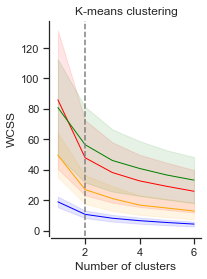

In [25]:
# Plot WCSS (related to Supplementary Fig. 6)
# Save the WCSS
WT_WCSS["Genotype"] = "WT"
Tbr1_WCSS["Genotype"] = "Tbr1"

All_WCSS = WT_WCSS.append(Tbr1_WCSS)
# All_WCSS.to_csv(savecsv + "WCSS_all.csv")

#################################################################
# Separate different group
WT_Water_WCSS_mean = []
WT_Water_WCSS_sem = []

WT_Cocktail_WCSS_mean = []
WT_Cocktail_WCSS_sem = []

Tbr1_Water_WCSS_mean = []
Tbr1_Water_WCSS_sem = []

Tbr1_Cocktail_WCSS_mean = []
Tbr1_Cocktail_WCSS_sem = []

for i in range(1,7):
    WT_Water_wcss_mean = All_WCSS[(All_WCSS["Group"]== "WT_Water") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    WT_Water_wcss_sem = All_WCSS[(All_WCSS["Group"]== "WT_Water") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    WT_Water_WCSS_mean.append(WT_Water_wcss_mean[0])
    WT_Water_WCSS_sem.append(WT_Water_wcss_sem[0])
    
    WT_Cocktail_wcss_mean = All_WCSS[(All_WCSS["Group"]== "WT_Cocktail") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    WT_Cocktail_wcss_sem = All_WCSS[(All_WCSS["Group"]== "WT_Cocktail") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    WT_Cocktail_WCSS_mean.append(WT_Cocktail_wcss_mean[0])
    WT_Cocktail_WCSS_sem.append(WT_Cocktail_wcss_sem[0])
    
    Tbr1_Water_wcss_mean = All_WCSS[(All_WCSS["Group"]== "Tbr1_Water") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    Tbr1_Water_wcss_sem = All_WCSS[(All_WCSS["Group"]== "Tbr1_Water") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    Tbr1_Water_WCSS_mean.append(Tbr1_Water_wcss_mean[0])
    Tbr1_Water_WCSS_sem.append(Tbr1_Water_wcss_sem[0])
    
    Tbr1_Cocktail_wcss_mean = All_WCSS[(All_WCSS["Group"]== "Tbr1_Cocktail") & (All_WCSS["Cluster"]== i)].mean(axis=0).values
    Tbr1_Cocktail_wcss_sem = All_WCSS[(All_WCSS["Group"]== "Tbr1_Cocktail") & (All_WCSS["Cluster"]== i)].sem(axis=0).values
    Tbr1_Cocktail_WCSS_mean.append(Tbr1_Cocktail_wcss_mean[0])
    Tbr1_Cocktail_WCSS_sem.append(Tbr1_Cocktail_wcss_sem[0])
    

# Calculate mean and sem in each group
WT_Water_WCSS_mean = np.array(WT_Water_WCSS_mean)
WT_Water_WCSS_sem = np.array(WT_Water_WCSS_sem)
WT_Cocktail_WCSS_mean = np.array(WT_Cocktail_WCSS_mean)
WT_Cocktail_WCSS_sem = np.array(WT_Cocktail_WCSS_sem)

Tbr1_Water_WCSS_mean = np.array(Tbr1_Water_WCSS_mean)
Tbr1_Water_WCSS_sem = np.array(Tbr1_Water_WCSS_sem)
Tbr1_Cocktail_WCSS_mean = np.array(Tbr1_Cocktail_WCSS_mean)
Tbr1_Cocktail_WCSS_sem = np.array(Tbr1_Cocktail_WCSS_sem)

#################################################################
# Plot WCSS
plt.figure(figsize=(3,4))
x= list(range(1,7))
Group_color = ["red", "orange", "green", "blue"]


plt.plot (x, WT_Water_WCSS_mean, color=Group_color[0], linewidth=1)
plt.fill_between (x, WT_Water_WCSS_mean-WT_Water_WCSS_sem, 
                     WT_Water_WCSS_mean+WT_Water_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[0])

plt.plot (x, Tbr1_Water_WCSS_mean, color=Group_color[1], linewidth=1)
plt.fill_between (x, Tbr1_Water_WCSS_mean-Tbr1_Water_WCSS_sem, 
                     Tbr1_Water_WCSS_mean+Tbr1_Water_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[1])

plt.plot (x, WT_Cocktail_WCSS_mean, color=Group_color[2], linewidth=1)
plt.fill_between (x, WT_Cocktail_WCSS_mean-WT_Cocktail_WCSS_sem, 
                     WT_Cocktail_WCSS_mean+WT_Cocktail_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[2])

plt.plot (x, Tbr1_Cocktail_WCSS_mean, color=Group_color[3], linewidth=1)
plt.fill_between (x, Tbr1_Cocktail_WCSS_mean-Tbr1_Cocktail_WCSS_sem, 
                     Tbr1_Cocktail_WCSS_mean+Tbr1_Cocktail_WCSS_sem, 
                  alpha=0.1, edgecolor="none", color= Group_color[3])


plt.title("K-means clustering", fontsize=12)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axvline(x=2, color="grey", linestyle="--")

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.tight_layout()
sns.despine(offset=2)


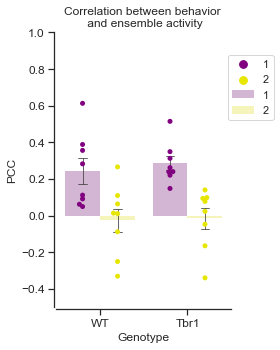

In [26]:
# Plot the correlation between behavior and ensemble activity (related to Fig. 2C; data redrawn in Prism)

# Combine PCC of WT and Tbr1
WT_Ensemble_behavior_PCC["Genotype"] = "WT"
Tbr1_Ensemble_behavior_PCC["Genotype"] = "Tbr1"

All_Ensemble_behavior_PCC = WT_Ensemble_behavior_PCC.append(Tbr1_Ensemble_behavior_PCC)
All_Ensemble_behavior_PCC


# Plot the correlation
plt.figure (figsize = (4,5))

new_spot_color1 =  {1:"purple", 2:"yellow"}
sns.set(style="ticks")
ax = sns.barplot(x="Genotype", y="PCC", hue="Ensemble", data=All_Ensemble_behavior_PCC,
                 palette=new_spot_color1,
                 alpha=0.3, errwidth=.8, capsize=.1,
                 hue_order=[1, 2], 
                 ci=68, linewidth=.0
                )

ax = sns.swarmplot(x="Genotype", y="PCC", hue="Ensemble", data=All_Ensemble_behavior_PCC,
                   size=5, dodge=True, alpha=1,
                   hue_order=[1,2], 
                   palette=["purple", "#E6E600"]
                  )

ax.set_xlabel(ax.get_xlabel(), size=12)
ax.set_ylabel(ax.get_ylabel(), size=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set(ylim=(-.5, 1))
ax.legend(loc='center left', bbox_to_anchor=(0.95, 0.8))

plt.title('Correlation between behavior \n and ensemble activity', fontsize=12)

plt.tight_layout()
sns.despine(offset=2)


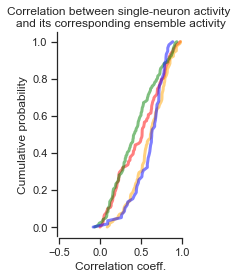

In [27]:
# Plot the correlation between single neuronal activity and its belonging ensemble activity across two RSI sessions (related to Fig. 2F)

plt.figure (figsize = (3,4))

# plot cumulative curve
x1 = np.sort(WT_Single_ensemble_PCC["Water_RSI"].dropna())  # sort data
y1 = 1.*np.arange(len(WT_Single_ensemble_PCC["Water_RSI"].dropna()))/(len(WT_Single_ensemble_PCC["Water_RSI"].dropna())-1)  #calculate CDF values

x2 = np.sort(Tbr1_Single_ensemble_PCC["Water_RSI"].dropna())
y2 = 1.*np.arange(len(Tbr1_Single_ensemble_PCC["Water_RSI"].dropna()))/(len(Tbr1_Single_ensemble_PCC["Water_RSI"].dropna())-1)

x3 = np.sort(WT_Single_ensemble_PCC["Cocktail_RSI"].dropna())
y3 = 1.*np.arange(len(WT_Single_ensemble_PCC["Cocktail_RSI"].dropna()))/(len(WT_Single_ensemble_PCC["Cocktail_RSI"].dropna())-1)

x4 = np.sort(Tbr1_Single_ensemble_PCC["Cocktail_RSI"].dropna())
y4 = 1.*np.arange(len(Tbr1_Single_ensemble_PCC["Cocktail_RSI"].dropna()))/(len(Tbr1_Single_ensemble_PCC["Cocktail_RSI"].dropna())-1)

PCC_color = ["red", "orange", "green", "blue"]

plt.plot(x1, y1, linewidth=3, color=PCC_color[0], alpha=0.5)
plt.plot(x2, y2, linewidth=3, color=PCC_color[1], alpha=0.5)
plt.plot(x3, y3, linewidth=3, color=PCC_color[2], alpha=0.5)
plt.plot(x4, y4, linewidth=3, color=PCC_color[3], alpha=0.5)

plt.xlim([-.5,1])
plt.title("Correlation between single-neuron activity \nand its corresponding ensemble activity", fontsize=12)
plt.xlabel("Correlation coeff.", fontsize=12)
plt.ylabel("Cumulative probability", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.tight_layout()
sns.despine(offset=2)


In [28]:
from scipy import stats

# Statistic in correlation between single-neuron activity and its corresponding ensemble activity
# Two-sample KS Test
d_statistic_1, p_value_1 = stats.ks_2samp(WT_Single_ensemble_PCC["Water_RSI"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Water_RSI"].dropna().values)


d_statistic_2, p_value_2 = stats.ks_2samp(WT_Single_ensemble_PCC["Cocktail_RSI"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Cocktail_RSI"].dropna().values)


d_statistic_3, p_value_3 = stats.ks_2samp(WT_Single_ensemble_PCC["Water_RSI"].dropna().values,
                                          WT_Single_ensemble_PCC["Cocktail_RSI"].dropna().values)


d_statistic_4, p_value_4 = stats.ks_2samp(Tbr1_Single_ensemble_PCC["Water_RSI"].dropna().values,
                                          Tbr1_Single_ensemble_PCC["Cocktail_RSI"].dropna().values)


KS_name_list = ["WT_water vs. Tbr1_water", "WT_cocktail vs. Tbr1_cocktail", 
                "WT_water vs. WT_cocktail", "Tbr1_water vs. Tbr1_cocktail"]

KS_statistic_all = [d_statistic_1, d_statistic_2, d_statistic_3, d_statistic_4]
KS_p_all = [p_value_1, p_value_2, p_value_3, p_value_4]

KS_test_table = pd.DataFrame(list(zip(KS_name_list, KS_statistic_all, KS_p_all)), 
                                columns = ["Two-sample KS Test", "D statistic", "P-value"])

KS_test_table

,Two-sample KS Test,D statistic,P-value
0,WT_water vs. Tbr1_water,0.247533,0.001601
1,WT_cocktail vs. Tbr1_cocktail,0.377211,0.000006
2,WT_water vs. WT_cocktail,0.144848,0.106289
3,Tbr1_water vs. Tbr1_cocktail,0.149353,0.324518


Text(0.1, 0.96, 'pearsonr = 0.2241, p = 0.4041')

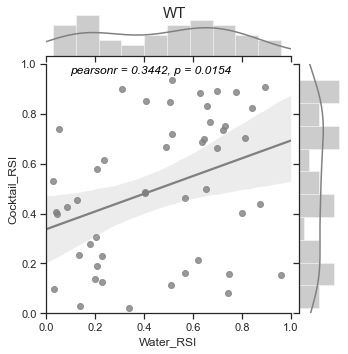

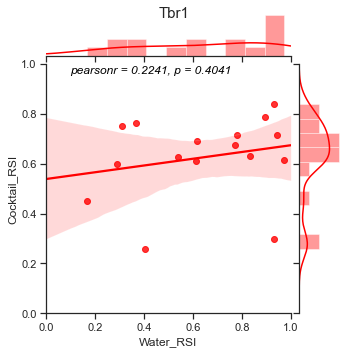

In [29]:
# Plot the correlation between single neuronal activity and its belonging ensemble activity across two RSI sessions (related to Fig. 2F)

#remove nan
WT_Single_ensemble_PCC_drpona = WT_Single_ensemble_PCC.dropna(subset=["Water_RSI","Cocktail_RSI"])
Tbr1_Single_ensemble_PCC_drpona = Tbr1_Single_ensemble_PCC.dropna(subset=["Water_RSI","Cocktail_RSI"])

#WT
g1 = sns.jointplot(x="Water_RSI", y="Cocktail_RSI", data=WT_Single_ensemble_PCC_drpona,
                  kind="reg", truncate=False,
                  xlim=(0,1), ylim=(0,1),
                  color="grey", height=5,
                  marginal_kws=dict(bins=10)
                  )
g1.fig.suptitle('WT',fontsize=15)

r1, p1 = pearsonr(WT_Single_ensemble_PCC_drpona["Water_RSI"], WT_Single_ensemble_PCC_drpona["Cocktail_RSI"])
plt.text(0.1,0.96, "pearsonr = "+str(round(r1, 4))+", p = "+ str(round(p1,4)), 
         fontsize = 12, color='black', fontstyle='italic')


#Tbr1
g2 = sns.jointplot(x="Water_RSI", y="Cocktail_RSI", data=Tbr1_Single_ensemble_PCC_drpona,
                  kind="reg", truncate=False,
                  xlim=(0,1), ylim=(0,1),
                  color="red", height=5,
                  marginal_kws=dict(bins=10)
                  )
g2.fig.suptitle('Tbr1',fontsize=15)

r2, p2 = pearsonr(Tbr1_Single_ensemble_PCC_drpona["Water_RSI"], Tbr1_Single_ensemble_PCC_drpona["Cocktail_RSI"])
plt.text(0.1,0.96, "pearsonr = "+str(round(r2, 4))+", p = "+ str(round(p2,4)), 
         fontsize = 12, color='black', fontstyle='italic')
